In [1]:
import json
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.utils.data as D
from src.dataset import ETHDataset, UCYDataset, SDDDataset, GCDataset, WayMoDataset, ORCADataset

_logger = logging.getLogger("src.train")

In [2]:
from tqdm import tqdm
from argparse import Namespace

args = Namespace(**json.load(open('logs/train/20251127_RelativeModel_添加ReLU_修改Freq_添加Anchor_153734_DL4/args.json', 'r')))
args.batch_size = 1

100%|██████████| 2/2 [00:00<00:00,  3.22it/s]


(np.float64(-19.06721747919642),
 np.float64(64.93032706781946),
 np.float64(-27.08524155701053),
 np.float64(35.61759018982303))

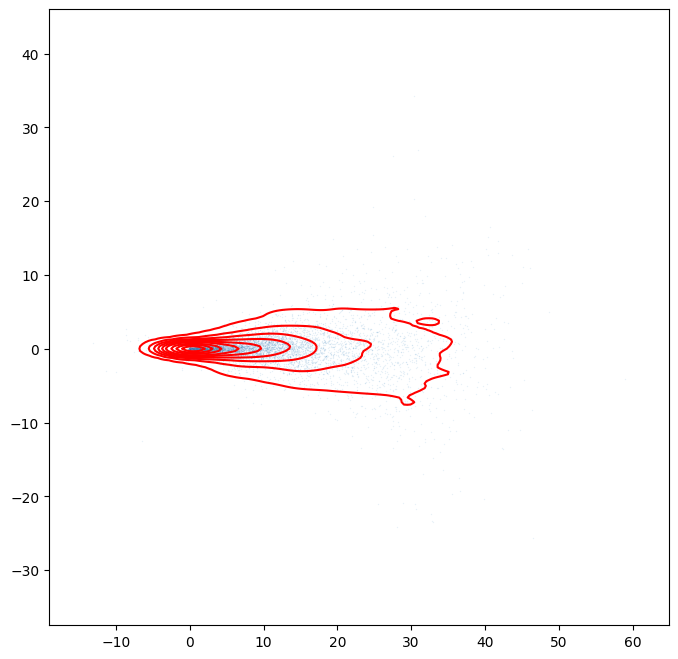

In [14]:
dataset_list = ETHDataset.load_data_batch(args, "./data/ETH/")
if True:
    # 创建数据加载器
    loader_list = []
    for dataset in dataset_list:
        if len(dataset) == 0:
            _logger.warning(f"Dataset {dataset.name} has no training samples!")
            continue
        loader_list.append(D.DataLoader(
            dataset,
            shuffle=True,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
            collate_fn=dataset.collate_fn,
        ))

    des_list = []
    for loader in tqdm(loader_list):
        for batch in loader:
            pos = batch['pos']
            vel = batch['vel']
            des = batch['des']

            des -= pos
            des_x = des[..., 0] * vel[..., 0] + des[..., 1] * vel[..., 1]
            des_y = -des[..., 0] * vel[..., 1] + des[..., 1] * vel[..., 0]
            des = np.stack([des_x, des_y], axis=-1) # (B, N, 2)
            des_list.append(des.reshape(-1, 2))
    des = np.concatenate(des_list, axis=0) # (总样本数, 2)

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=des[:, 0], y=des[:, 1], s=1, alpha=0.1, ax=ax)
sns.kdeplot(x=des[:, 0], y=des[:, 1], levels=10, color='red', ax=ax)
ax.axis('equal')

100%|██████████| 7/7 [00:01<00:00,  4.61it/s]


(np.float64(-29.552167678373543),
 np.float64(74.84926011611769),
 np.float64(-43.27397222832743),
 np.float64(43.421341613093055))

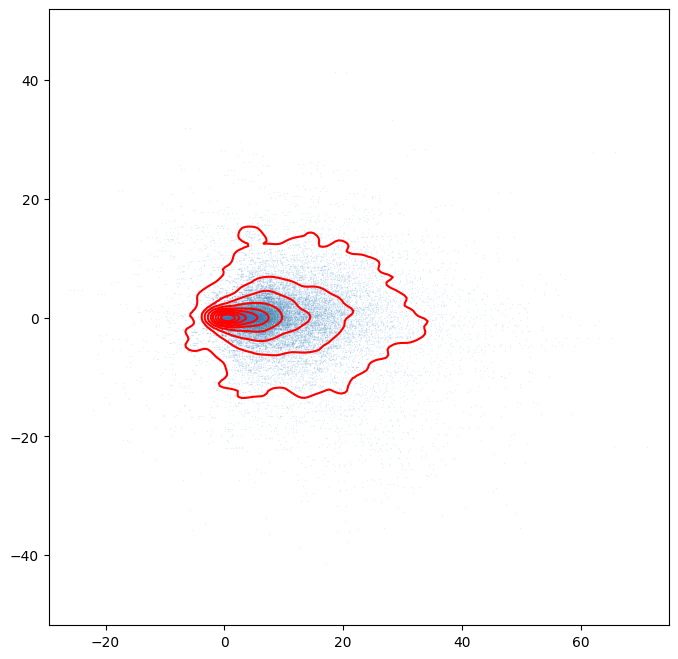

In [15]:
dataset_list = UCYDataset.load_data_batch(args, "./data/UCY/data/")
if True:
    # 创建数据加载器
    loader_list = []
    for dataset in dataset_list:
        if len(dataset) == 0:
            _logger.warning(f"Dataset {dataset.name} has no training samples!")
            continue
        loader_list.append(D.DataLoader(
            dataset,
            shuffle=True,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
            collate_fn=dataset.collate_fn,
        ))

    des_list = []
    for loader in tqdm(loader_list):
        for batch in loader:
            pos = batch['pos']
            vel = batch['vel']
            des = batch['des']

            des -= pos
            des_x = des[..., 0] * vel[..., 0] + des[..., 1] * vel[..., 1]
            des_y = -des[..., 0] * vel[..., 1] + des[..., 1] * vel[..., 0]
            des = np.stack([des_x, des_y], axis=-1) # (B, N, 2)
            des_list.append(des.reshape(-1, 2))
    des = np.concatenate(des_list, axis=0) # (总样本数, 2)

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=des[:, 0], y=des[:, 1], s=1, alpha=0.1, ax=ax)
sns.kdeplot(x=des[:, 0], y=des[:, 1], levels=10, color='red', ax=ax)
ax.axis('equal')

100%|██████████| 1/1 [00:04<00:00,  4.48s/it]


(np.float64(-194.49555130004882),
 np.float64(400.62883682250975),
 np.float64(-217.33527755737305),
 np.float64(165.73540878295898))

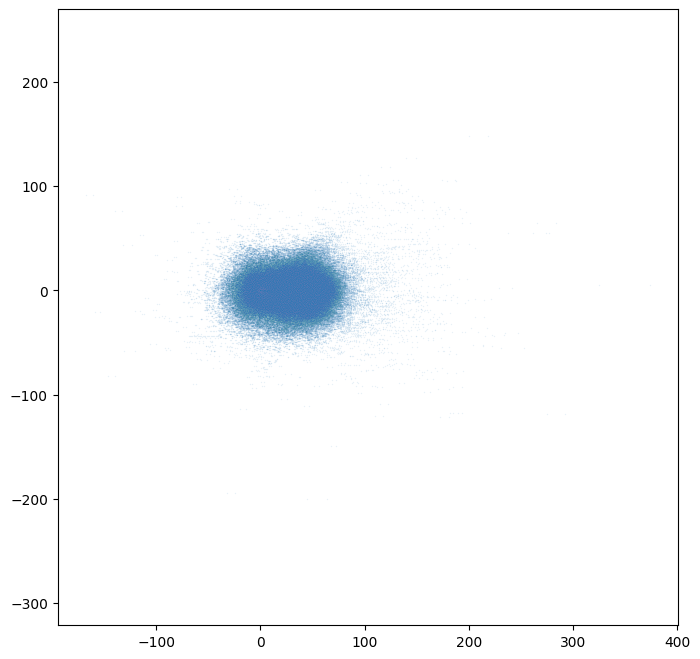

In [10]:
dataset_list = [GCDataset.load_data(args, "./data/GC/Annotation")]
if True:
    # 创建数据加载器
    loader_list = []
    for dataset in dataset_list:
        if len(dataset) == 0:
            _logger.warning(f"Dataset {dataset.name} has no training samples!")
            continue
        loader_list.append(D.DataLoader(
            dataset,
            shuffle=True,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
            collate_fn=dataset.collate_fn,
        ))

    des_list = []
    for loader in tqdm(loader_list):
        for batch in tqdm(loader):
            pos = batch['pos']
            vel = batch['vel']
            des = batch['des']

            des -= pos
            des_x = des[..., 0] * vel[..., 0] + des[..., 1] * vel[..., 1]
            des_y = -des[..., 0] * vel[..., 1] + des[..., 1] * vel[..., 0]
            des = np.stack([des_x, des_y], axis=-1) # (B, N, 2)
            des_list.append(des.reshape(-1, 2))
    des = np.concatenate(des_list, axis=0) # (总样本数, 2)

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=des[:, 0], y=des[:, 1], s=1, alpha=0.1, ax=ax, rasterized=True)
# sns.kdeplot(x=des[:, 0], y=des[:, 1], levels=10, color='red', ax=ax)
ax.axis('equal')

100%|██████████| 60/60 [00:12<00:00,  4.65it/s]


(np.float64(-750.8962341308594),
 np.float64(2790.542352294922),
 np.float64(-811.2184509277344),
 np.float64(1851.822332763672))

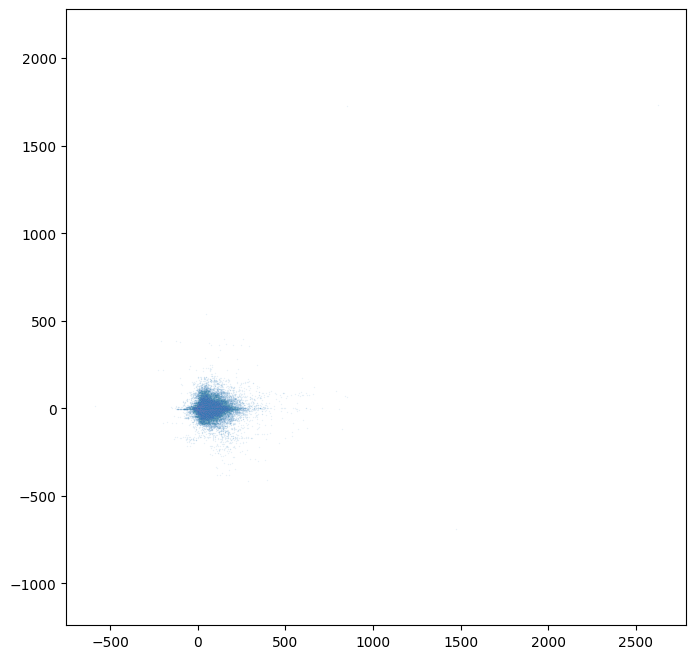

In [9]:
dataset_list = SDDDataset.load_data_batch(args, "./data/SDD/annotations/")
if True:
    # 创建数据加载器
    loader_list = []
    for dataset in dataset_list:
        if len(dataset) == 0:
            _logger.warning(f"Dataset {dataset.name} has no training samples!")
            continue
        loader_list.append(D.DataLoader(
            dataset,
            shuffle=True,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
            collate_fn=dataset.collate_fn,
        ))

    des_list = []
    for loader in tqdm(loader_list):
        for batch in loader:
            pos = batch['pos']
            vel = batch['vel']
            des = batch['des']

            des -= pos
            des_x = des[..., 0] * vel[..., 0] + des[..., 1] * vel[..., 1]
            des_y = -des[..., 0] * vel[..., 1] + des[..., 1] * vel[..., 0]
            des = np.stack([des_x, des_y], axis=-1) # (B, N, 2)
            des_list.append(des.reshape(-1, 2))
    des = np.concatenate(des_list, axis=0) # (总样本数, 2)

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=des[:, 0], y=des[:, 1], s=1, alpha=0.1, ax=ax)
# sns.kdeplot(x=des[:, 0], y=des[:, 1], levels=10, color='red', ax=ax)
ax.axis('equal')

100%|██████████| 100/100 [00:01<00:00, 86.98it/s]


(np.float64(-46.44905815124512),
 np.float64(544.5075374603272),
 np.float64(-50.32830295562744),
 np.float64(55.673811531066896))

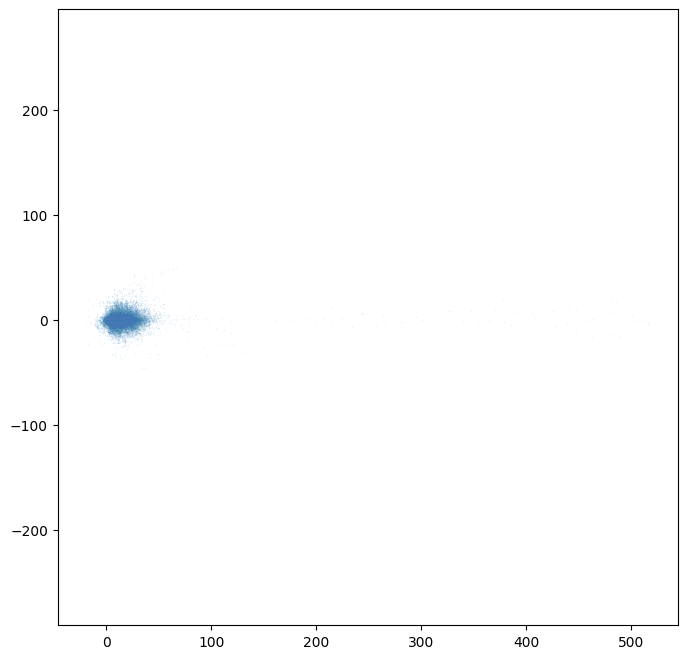

In [11]:
dataset_list = WayMoDataset.load_data_batch(args, "./data/WayMo/Processed/", total=100)
if True:
    # 创建数据加载器
    loader_list = []
    for dataset in dataset_list:
        if len(dataset) == 0:
            _logger.warning(f"Dataset {dataset.name} has no training samples!")
            continue
        loader_list.append(D.DataLoader(
            dataset,
            shuffle=True,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
            collate_fn=dataset.collate_fn,
        ))

    des_list = []
    for loader in tqdm(loader_list):
        for batch in loader:
            pos = batch['pos']
            vel = batch['vel']
            des = batch['des']

            des -= pos
            des_x = des[..., 0] * vel[..., 0] + des[..., 1] * vel[..., 1]
            des_y = -des[..., 0] * vel[..., 1] + des[..., 1] * vel[..., 0]
            des = np.stack([des_x, des_y], axis=-1) # (B, N, 2)
            des_list.append(des.reshape(-1, 2))
    des = np.concatenate(des_list, axis=0) # (总样本数, 2)

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=des[:, 0], y=des[:, 1], s=1, alpha=0.1, ax=ax)
# sns.kdeplot(x=des[:, 0], y=des[:, 1], levels=10, color='red', ax=ax)
ax.axis('equal')

In [ ]:
dataset_list = ORCADataset.load_data_batch(args, "./data/ORCA/")
args.datasets.remove("ORCA")
if True:
    # 创建数据加载器
    loader_list = []
    for dataset in dataset_list:
        if len(dataset) == 0:
            _logger.warning(f"Dataset {dataset.name} has no training samples!")
            continue
        loader_list.append(D.DataLoader(
            dataset,
            shuffle=True,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
            collate_fn=dataset.collate_fn,
        ))

    des_list = []
    for loader in tqdm(loader_list):
        for batch in loader:
            pos = batch['pos']
            vel = batch['vel']
            des = batch['des']

            des -= pos
            des_x = des[..., 0] * vel[..., 0] + des[..., 1] * vel[..., 1]
            des_y = -des[..., 0] * vel[..., 1] + des[..., 1] * vel[..., 0]
            des = np.stack([des_x, des_y], axis=-1) # (B, N, 2)
            des_list.append(des.reshape(-1, 2))
    des = np.concatenate(des_list, axis=0) # (总样本数, 2)

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=des[:, 0], y=des[:, 1], s=1, alpha=0.1, ax=ax)
sns.kdeplot(x=des[:, 0], y=des[:, 1], levels=10, color='red', ax=ax)